## Figure 4 - Cell-type specific coding and GLM analysis


In [1]:
import visual_behavior_glm.GLM_visualization_tools as gvt
import visual_behavior_glm.GLM_fit_dev as gfd
import visual_behavior_glm.GLM_cell_metrics as gcm
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import visual_behavior.data_access.loading as loading
import visual_behavior.data_access.utilities as utilities
import visual_behavior.visualization.utils as utils

from visual_behavior.dimensionality_reduction.clustering import plotting
from visual_behavior.dimensionality_reduction.clustering import processing

import visual_behavior.visualization.ophys.glm_example_plots as gep
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache



%load_ext autoreload
%autoreload 2
%matplotlib inline

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain 

In [2]:
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

glm_version = '24_events_all_L2_optimize_by_session'

save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_4')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

### Data Loading

#### Metadata Tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

#### GLM results

In [4]:

# GLM results loading
glm_results_dir = loading.get_glm_results_dir()
run_params = pd.read_pickle(os.path.join(glm_results_dir, glm_version + '_run_params.pkl'))
run_params['figure_dir'] = os.path.join(save_dir, 'coding_scores_and_kernels')

kernels = run_params['kernels']

all_weights_df = pd.read_hdf(os.path.join(glm_results_dir, 'weights_df.h5'), key='df')
all_results = pd.read_hdf(os.path.join(glm_results_dir, 'all_results.h5'), key='df')
all_results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'results_pivoted.h5'), key='df')
all_results_pivoted = processing.set_negative_one_values_to_zero(all_results_pivoted)

# Split out cell_specimen_id and ophys_experiment_id for results table
all_results['cell_specimen_id'] = [int(identifier.split('_')[1]) for identifier in all_results.identifier.values]
all_results['ophys_experiment_id'] = [int(identifier.split('_')[0]) for identifier in all_results.identifier.values]

# Get results and weights just for platform paper experiments
results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'platform_results_pivoted.h5'), key='df')
results_pivoted = processing.set_negative_one_values_to_zero(results_pivoted)
# Make coding scores positive
results_pivoted[processing.get_features_for_clustering()] = np.abs(results_pivoted[processing.get_features_for_clustering()])
# # Add relevant metadata
results_pivoted = results_pivoted.merge(platform_experiments[['cell_type', 'binned_depth']], on='ophys_experiment_id', how='left')

# Weights dataframe for platform paper experiments
weights_df = pd.read_hdf(os.path.join(glm_results_dir, 'platform_results_weights_df.h5'), key='df')
weights_df['experience_level'] = [utils.convert_experience_level(experience_level) for experience_level in weights_df.experience_level.values]

# Plotting utilities initialization
feature_colors, feature_labels_dict = plotting.get_feature_colors_and_labels()


In [5]:
# Load GLM example cell data for single cell examples
example_cells_dict, example_times_dict = gep.get_glm_example_cells_and_times()



### Kernel support and example cells


In [6]:

# # Plot kernel support visualization
# gvt.plot_kernel_support(results_pivoted)

In [7]:
# Load GLM example cell data for single cell examples
example_cells_dict, example_times_dict = gep.get_glm_example_cells_and_times()


In [8]:
# ophys_experiment_id = 1076808556

# # Plot GLM example cells figure
# gep.plot_glm_example_cells_figure(
#     ophys_experiment_id, run_params, all_results, results_pivoted, weights_df,
#     use_var_exp=True, save_dir=save_dir)


### Example cell with GLM fit and behavior/physio timeseries

Load behavior and physiology timeseries example

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

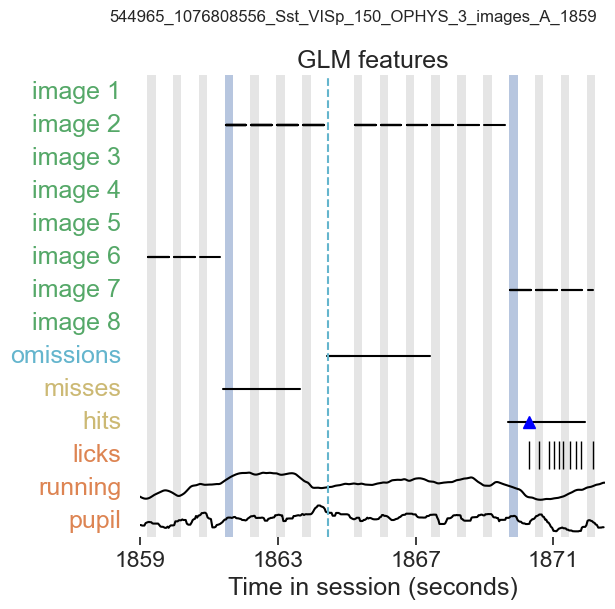

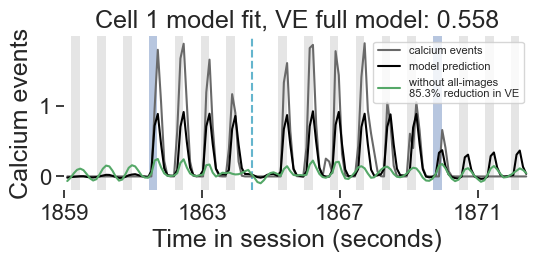

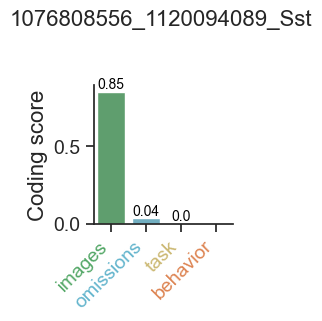

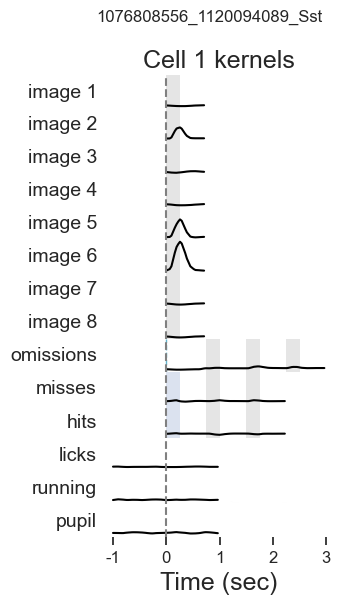

In [11]:
# 544965 - Sst
start_time = 1859

# image coding
ophys_experiment_id = 1076808556
cell_specimen_id = 1120094089

dataset = loading.get_ophys_dataset(ophys_experiment_id)
cell_results_df, expt_results, dropouts = gep.load_glm_model_fit_results(ophys_experiment_id)

### Get time window
flashes_between_changes = 12
four_flash_dur = 6*0.75
xlim_seconds = [start_time, start_time+(flashes_between_changes*0.75)+four_flash_dur]
duration_seconds = (flashes_between_changes*0.75)+four_flash_dur
suffix = '_' + str(int(xlim_seconds[0]))

gep.plot_glm_features_for_window(dataset, xlim_seconds, title = 'GLM features',
                                 save_dir=save_dir, folder='example_cells', ax=None, suffix=suffix);

gep.plot_model_fits_example_cell(cell_specimen_id, dataset, cell_results_df, dropouts, expt_results, 
                                        'all-images', title = 'Cell 1 model fit',
                                        twinx=False, include_events=True, include_dff=False, 
                                        times=xlim_seconds, save_dir=save_dir, folder='example_cells');

gep.plot_coding_score_components_for_cell(cell_specimen_id, ophys_experiment_id, results_pivoted, dataset,
                                            title='', horiz=False, fontsize=14, as_panel=False, save_dir=save_dir, folder='example_cells');

gep.plot_stacked_kernels_for_cell(cell_specimen_id, dataset, weights_df, kernels, sharey=True,
                                    title='Cell 1 kernels', save_dir=save_dir, folder='example_cells', scale_y=False);

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

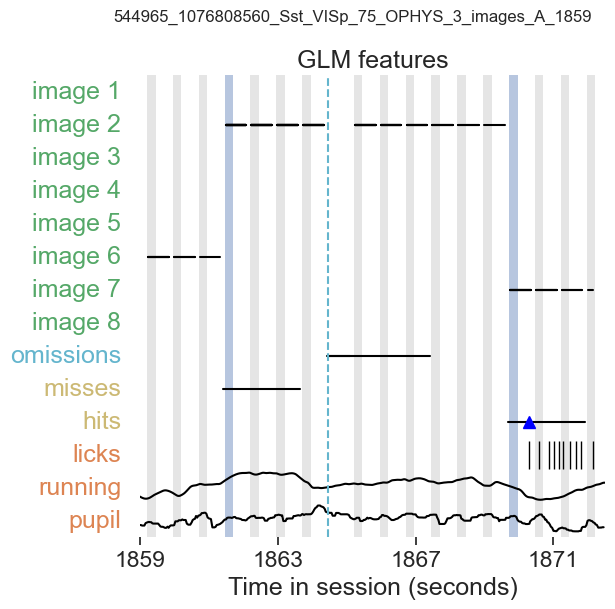

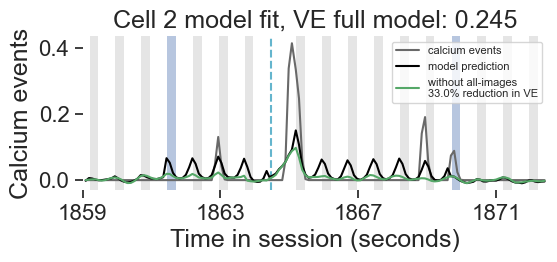

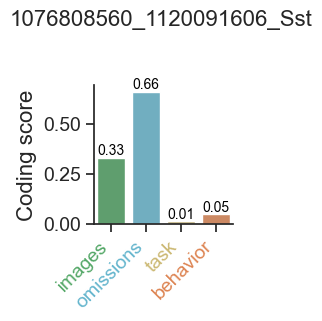

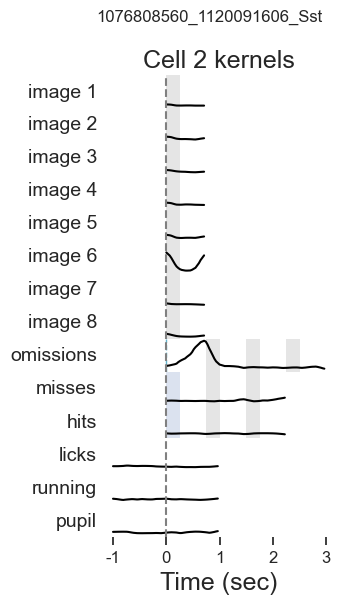

In [12]:
# 544965 - Sst
start_time = 1859

# omission coding
ophys_experiment_id = 1076808560
cell_specimen_id = 1120091606


dataset = loading.get_ophys_dataset(ophys_experiment_id)
cell_results_df, expt_results, dropouts = gep.load_glm_model_fit_results(ophys_experiment_id)

### Get time window
flashes_between_changes = 12
four_flash_dur = 6*0.75
xlim_seconds = [start_time, start_time+(flashes_between_changes*0.75)+four_flash_dur]
duration_seconds = (flashes_between_changes*0.75)+four_flash_dur
suffix = '_' + str(int(xlim_seconds[0]))


gep.plot_glm_features_for_window(dataset, xlim_seconds, title = 'GLM features',
                                 save_dir=save_dir, folder='example_cells', ax=None, suffix=suffix);

gep.plot_model_fits_example_cell(cell_specimen_id, dataset, cell_results_df, dropouts, expt_results, 
                                        'all-images', title = 'Cell 2 model fit',
                                        twinx=False, include_events=True, include_dff=False, 
                                        times=xlim_seconds, save_dir=save_dir, folder='example_cells');

gep.plot_coding_score_components_for_cell(cell_specimen_id, ophys_experiment_id, results_pivoted, dataset, title='',
                                            horiz=False, fontsize=14, as_panel=False, save_dir=save_dir, folder='example_cells');

gep.plot_stacked_kernels_for_cell(cell_specimen_id, dataset, weights_df, kernels, sharey=True,
                                    title='Cell 2 kernels', save_dir=save_dir, folder='example_cells', scale_y=False);

#### Additional Vip examples

In [13]:
vips = results_pivoted[(results_pivoted.cell_type=='Vip Inhibitory') & 
                                    (results_pivoted.variance_explained_full>0.1) & 
                                    (results_pivoted['omissions']>0.5)].identifier.values

len(vips)

4

In [14]:
# Get saved example cells and event times of interest
example_cells_dict, example_times_dict = gep.get_glm_example_cells_and_times()
# Use custom selection
example_cells_dict = {974994093: [1086537043],
                        974994095: [1086519261],
                        974994101: [1086518655],
                        974994105: [1086524231],
                        # 905955213: [1086532875],
                        # 905955219: [1086509036],
                        1076808560: [1120091440, 1120091606],
                        1076808556: [1120094089, 1120094237, 1120094842]}


vip_example_cells_dict = {1053997501: [1086612555],
                        # 795953296: [1086490680],
                        851085100: [1086501664],
                        851085100: [1086501719]}

In [15]:
# folder = 'example_cells'

# for i, ophys_experiment_id in enumerate(list(vip_example_cells_dict.keys())):

#     ### Get data
#     dataset = loading.get_ophys_dataset(ophys_experiment_id)
#     cell_results_df, expt_results, dropouts = gep.load_glm_model_fit_results(ophys_experiment_id)

#     for cell_specimen_id in vip_example_cells_dict[ophys_experiment_id]:

        

#         ### Plot kernels and coding scores 
#         gep.plot_stacked_kernels_for_cell(cell_specimen_id, dataset, weights_df, kernels, 
#                                         save_dir=save_dir, folder=folder);

#         gep.plot_coding_score_components_for_cell(cell_specimen_id, ophys_experiment_id, results_pivoted, dataset,
#                                                     fontsize=14, as_panel=False, save_dir=save_dir, folder=folder);
    
#     ### Get time window
#     flashes_between_changes = 12
#     four_flash_dur = 6*0.75
#     start_times = utils.get_consecutive_trials_with_omission_in_middle(dataset, flashes_between_changes=flashes_between_changes)
#     for start_time in start_times[:5]:
#         xlim_seconds = [start_time, start_time+(flashes_between_changes*0.75)+four_flash_dur]
#         duration_seconds = (flashes_between_changes*0.75)+four_flash_dur
#         suffix = '_' + str(int(xlim_seconds[0]))

#         ### Plot GLM features 
#         gep.plot_glm_features_for_window(dataset, xlim_seconds, save_dir=save_dir, folder=folder, ax=None, suffix=suffix);

#         #### Plot model fit
#         gep.plot_model_fits_example_cell(cell_specimen_id, dataset, cell_results_df, dropouts, expt_results, 
#                                         'all-images', twinx=False, include_events=True, include_dff=False, 
#                                         times=xlim_seconds, save_dir=save_dir, folder=folder);     



#### Additional Sst & Excitatory examples

In [16]:
# folder = 'example_cells'

# for i, ophys_experiment_id in enumerate(list(example_cells_dict.keys())):
#     print(ophys_experiment_id)

#     ### Get data
#     dataset = loading.get_ophys_dataset(ophys_experiment_id)
#     cell_results_df, expt_results, dropouts = gep.load_glm_model_fit_results(ophys_experiment_id)

        
#     for cell_specimen_id in example_cells_dict[ophys_experiment_id]:

#         ### Get time window
#         start_time = example_times_dict[ophys_experiment_id][0]
#         flashes_between_changes = 12
#         four_flash_dur = 6*0.75
#         xlim_seconds = [start_time, start_time+(flashes_between_changes*0.75)+four_flash_dur]
#         duration_seconds = (flashes_between_changes*0.75)+four_flash_dur
#         suffix = '_' + str(int(xlim_seconds[0]))

#         ### Plot GLM features 
#         gep.plot_glm_features_for_window(dataset, xlim_seconds, save_dir=save_dir, folder=folder, ax=None, suffix=suffix);

#         #### Plot model fit
#         gep.plot_model_fits_example_cell(cell_specimen_id, dataset, cell_results_df, dropouts, expt_results, 
#                                         'all-images', twinx=False, include_events=True, include_dff=False, 
#                                     times=xlim_seconds, save_dir=save_dir, folder=folder);

#         ### Plot kernels and coding scores 
#         gep.plot_stacked_kernels_for_cell(cell_specimen_id, dataset, weights_df, kernels, 
#                                         save_dir=save_dir, folder=folder);

#         gep.plot_coding_score_components_for_cell(cell_specimen_id, ophys_experiment_id, results_pivoted, dataset,
#                                                     fontsize=14, as_panel=False, save_dir=save_dir, folder=folder);





### Image kernels for all cells 

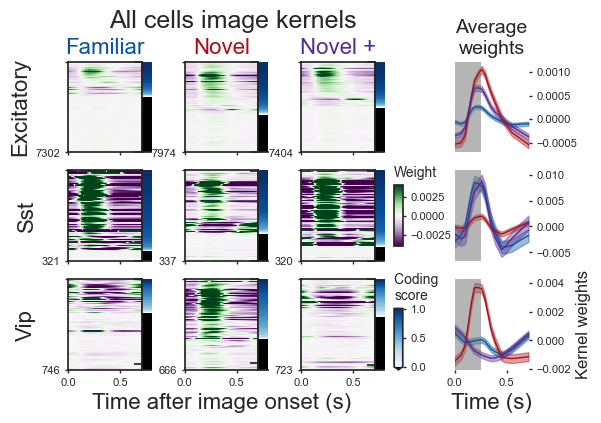

In [17]:
gep.plot_weights_and_coding_score_heatmaps_for_experience_levels_main_figure(
    'all-images', weights_df, run_params,
    row_condition='cre_line', col_condition='experience_level',
    vmax=0.004, xlabel='Time after image onset (s)', suptitle='All cells image kernels',
    save_dir=save_dir, folder='kernel_weights')


### Fraction cells coding for features

In [18]:
var_explained_thresh = run_params['dropout_threshold'] # 0.01 # stricter than inclusion threshold of 0.005
coding_thresh = 0.1

# compute coding fractions
results_pivoted = results_pivoted.query('not passive').copy()
results_pivoted['code_anything'] = results_pivoted['variance_explained_full'] > run_params['dropout_threshold'] 
results_pivoted['code_images'] = results_pivoted['code_anything'] & (results_pivoted['all-images'] > coding_thresh)
results_pivoted['code_omissions'] = results_pivoted['code_anything'] & (results_pivoted['omissions'] > coding_thresh)
results_pivoted['code_behavioral'] = results_pivoted['code_anything'] & (results_pivoted['behavioral'] > coding_thresh)
results_pivoted['code_task'] = results_pivoted['code_anything'] & (results_pivoted['task'] > coding_thresh)

summary_df = results_pivoted.groupby(['cre_line'])[['code_anything','code_images','code_omissions','code_behavioral','code_task']].mean()
# Compute Confidence intervals
summary_df['n'] = results_pivoted.groupby(['cre_line'])[['code_anything','code_images','code_omissions','code_behavioral','code_task']].count()['code_anything']
summary_df['code_images_ci'] = 1.96*np.sqrt((summary_df['code_images']*(1-summary_df['code_images']))/summary_df['n'])
summary_df['code_omissions_ci'] = 1.96*np.sqrt((summary_df['code_omissions']*(1-summary_df['code_omissions']))/summary_df['n'])
summary_df['code_behavioral_ci'] = 1.96*np.sqrt((summary_df['code_behavioral']*(1-summary_df['code_behavioral']))/summary_df['n'])
summary_df['code_task_ci'] = 1.96*np.sqrt((summary_df['code_task']*(1-summary_df['code_task']))/summary_df['n'])

fractions = summary_df.copy()
fractions = fractions.drop(columns=['code_anything', 'n'])
fractions.columns = [column.split('_')[1] if 'ci' not in column else column.split('_')[1]+'_'+column.split('_')[2] for column in fractions.columns]
fractions = fractions.rename(columns={'behavioral':'behavior', 'behavioral_ci':'behavior_ci'})
fractions = fractions.reset_index()
fractions = fractions.melt(id_vars=['cre_line'], var_name='feature', value_name='fraction')

fractions['cell_type'] = [utils.convert_cre_line_to_cell_type(cre_line) for cre_line in fractions.cre_line.values]

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_56766/212480757.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=ct_data, x='feature', y='percent', order=features,
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_56766/212480757.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(features, rotation=45, ha='right', fontsize=14)
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_56766/212480757.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=ct_data, x='feature', y='percent', order=features,
/var/folders/1t/06qd1ncj5q90vctb

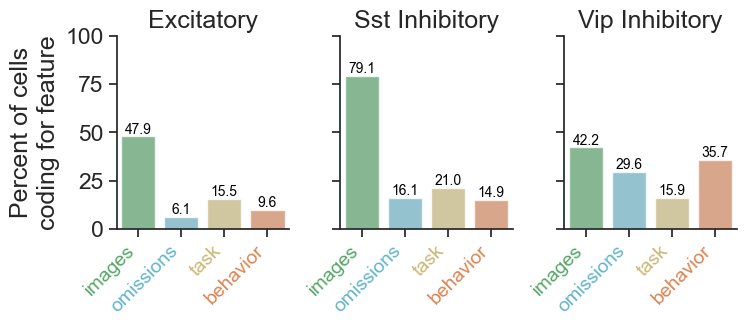

In [19]:
cell_types = utils.get_cell_types()
features = processing.get_feature_labels_for_clustering()

fractions['percent'] = fractions['fraction']* 100
figsize = (8, 2.5)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True, sharex=True)
ax = ax.ravel()

for i, cell_type in enumerate(cell_types): 
    ct_data = fractions[fractions.cell_type==cell_type]
    ax[i] = sns.barplot(data=ct_data, x='feature', y='percent', order=features, 
                            palette=feature_colors, width=0.8, alpha=0.75, ax=ax[i])
    
    # ax[i].set_title(cell_type)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].set_ylim(0, 100)

    if i == 0: 
        ax[i].set_ylabel('Percent of cells\ncoding for feature')
    else: 
        ax[i].set_ylabel('')

    ax[i].set_title(cell_type)

    for x, feature in enumerate(features):
        pct = ct_data[ct_data['feature']==feature].percent.values[0]
        ax[i].text(s = str(np.round(pct, 1)), y=pct, x=x, rotation=0, fontsize=10, 
                    color='k', va='bottom',  ha='center')

    ax[i].set_xticklabels(features, rotation=45, ha='right', fontsize=14)
    c_vals, feature_labels_dict = plotting.get_feature_colors_and_labels()
    [t.set_color(i) for (i,t) in zip([c_vals[0], c_vals[1], c_vals[2], c_vals[3]], ax[i].xaxis.get_ticklabels())]
    

# ax[0].legend(fontsize='x-small', bbox_to_anchor=(1.1, 1.2))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

filename = 'percent_cells_coding_feature'
utils.save_figure(fig, figsize, save_dir, 'coding_properties', filename)

#### Maximally contributing feature 

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_56766/130331640.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  results_pivoted_avg_per_cell = results_pivoted.groupby(['cre_line', 'cell_specimen_id']).mean().reset_index()
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_56766/130331640.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([utils.get_abbreviated_cell_type(cre_line) for cre_line in utils.get_cre_lines()])


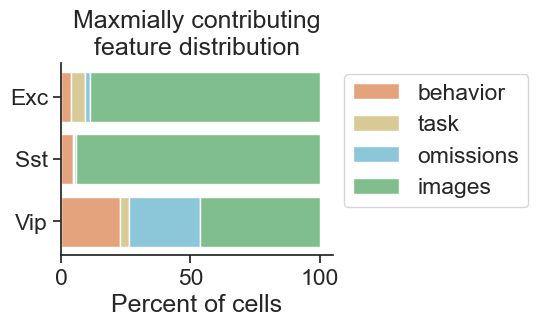

In [20]:
cells_table = matched_cells_table.copy()

# get average coding scores per cell for main features
results_pivoted_avg_per_cell = results_pivoted.groupby(['cre_line', 'cell_specimen_id']).mean().reset_index()
df = results_pivoted_avg_per_cell.set_index(['cell_specimen_id'])[processing.get_features_for_clustering()]
# df = df.set_index('cell_specimen_id')
df = np.abs(df)
# aggregate the feature with largest average coding score for each cell
max_feature = pd.DataFrame(df.index.values, columns=['cell_specimen_id'])
max_feature = max_feature.set_index('cell_specimen_id')
max_feature['max_feature'] = None
for csid in df.index.values:
    max_feature.loc[csid, 'max_feature'] = df.loc[csid].idxmax()
max_feature = max_feature.merge(cells_table[['cell_specimen_id', 'cre_line']], on=['cell_specimen_id'])

# count how many cells in each cre line have maximal coding for each feature
feature_counts = plotting.get_fraction_cells_for_column(max_feature, column_to_group = 'max_feature')
feature_counts.head()

feature_colors, feature_labels_dict = plotting.get_feature_colors_and_labels()
features = processing.get_feature_labels_for_clustering()


feature_counts['percent'] = feature_counts.fraction*100

figsize = (3.5,2.5)
fig, ax = plt.subplots(figsize=figsize)
feature_order = processing.get_features_for_clustering()
feature_labels = processing.get_feature_labels_for_clustering()[::-1] # for some reason legend shows colors in reverse order
ax = sns.histplot(feature_counts, y='cre_line', hue='max_feature', hue_order=feature_order, weights='percent',
            multiple='stack', palette=feature_colors, shrink=0.8, alpha=0.75, ax=ax)
ax.set_yticklabels([utils.get_abbreviated_cell_type(cre_line) for cre_line in utils.get_cre_lines()])
ax.legend(feature_labels, bbox_to_anchor=(1,1))
ax.set_xlabel('Percent of cells')
ax.set_ylabel('')
ax.set_title('Maxmially contributing\nfeature distribution')

utils.save_figure(fig, figsize, save_dir, 'coding_properties', 'maximally_contributing_feature_dimension')

### Coding score distributions across experience levels

In [21]:
# swap names of features 
results_melted = results_pivoted.copy()
results_melted['images'] = results_melted['all-images']
results_melted['behavior'] = results_melted['behavioral']

# get coding scores for main features
features = processing.get_feature_labels_for_clustering()
print(features)
metadata = ['cell_specimen_id', 'ophys_experiment_id', 'cre_line', 'experience_level']
results_melted = results_melted[features + metadata]

# transform coding scores for plotting
results_melted = results_melted.melt(id_vars=metadata, value_vars=features, var_name='feature', value_name='coding_score')

# take absolute value & convert exp level
results_melted['coding_score'] = np.abs(results_melted['coding_score'])
# results_melted['experience_level'] = [utils.convert_experience_level(exp_level) for exp_level in results_melted.experience_level.values]

len(results_melted.ophys_experiment_id.unique())

['images', 'omissions', 'task', 'behavior']


402

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_56766/2364996067.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(exp_level_abbreviations)
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_56766/2364996067.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(exp_level_abbreviations)
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_56766/2364996067.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(exp_level_abbreviations)
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_56766/2364996067.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].s

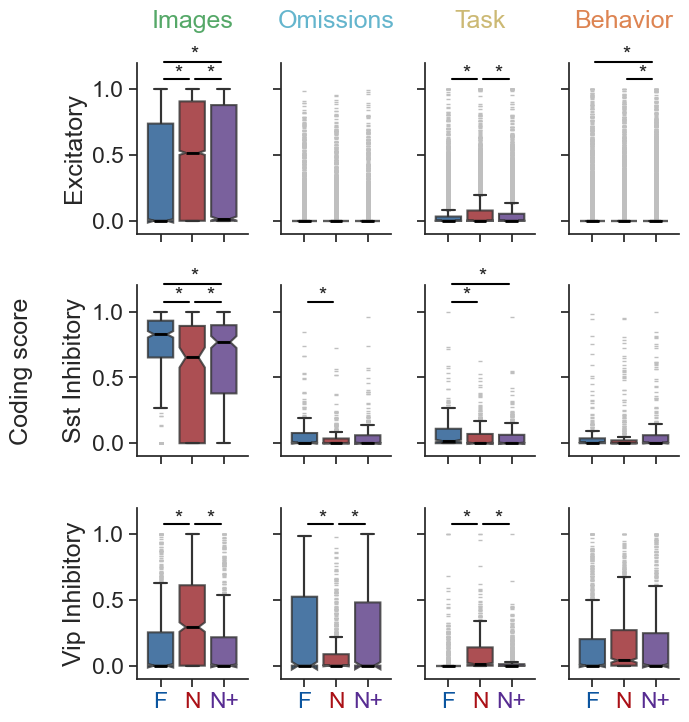

In [23]:
# boxprlot with outliers
experience_level_colors = utils.get_experience_level_colors()

figsize = (7, 8)
fig, ax = plt.subplots(3, 4, figsize=figsize, sharey=True)
ax = ax.ravel()
i=0
for c, cre_line in enumerate(cre_lines): 
    for f, feature in enumerate(features):
        results_pivoted_cre_feature = results_melted[(results_melted.cre_line==cre_line)
                                                    & (results_melted.feature==feature)].copy()
        
        ax[i] = sns.boxplot(data=results_pivoted_cre_feature, x='experience_level', y='coding_score',  order=experience_levels, 
                            hue='experience_level', hue_order=experience_levels, 
                            palette=experience_level_colors,  legend=False,
                            linewidth=1.5, width=0.7, fliersize=0, whis=1.5, notch=True, 
                            flierprops=dict(markerfacecolor='0.75', markersize=3, marker='_',
                                            linestyle='none', markeredgecolor='0.75'),
                            boxprops={'alpha':0}, ax=ax[i])
        ax[i] = sns.boxplot(data=results_pivoted_cre_feature, x='experience_level', y='coding_score',  order=experience_levels, 
                            hue='experience_level', hue_order=experience_levels, legend=False,
                            palette=experience_level_colors, notch=True, medianprops={"color": "k", "linewidth": 2}, 
                            linewidth=1.5, width=0.8, showfliers=False, whis=1.5, dodge=False,
                            boxprops={'alpha':0.8}, ax=ax[i])
        # ax[i].get_legend().remove()
        ax[i].set_ylabel('')
        ax[i].set_xlabel('')
        ax[i].set_xticklabels([])
        if c == 0: 
            ax[i].set_title(feature.capitalize()+'\n', color=feature_colors[f])
        # if c == 2: 
            # ax[i].set_xlabel(feature)
        if f == 0: 
            if c == 1: 
                ax[i].set_ylabel('Coding score\n\n'+utils.convert_cre_line_to_cell_type(cre_line))
            else:
                ax[i].set_ylabel(utils.convert_cre_line_to_cell_type(cre_line))

        if c == 2: 
            exp_level_abbreviations = [exp_level.split(' ')[0][0] if len(exp_level.split(' ')) == 1 else exp_level.split(' ')[0][0] + exp_level.split(' ')[1][:2] for exp_level in experience_levels]
            ax[i].set_xticklabels(exp_level_abbreviations)
            plotting.color_xaxis_labels_by_experience(ax[i])

        ax[i].set_ylim(-0.1, 1.1)
        ax[i].set_xlim(-0.75, 2.75)

        # add stats to plot for hues
        # ax[i], tukey_table = ppf.add_stats_to_plot(results_pivoted_cre_feature, 'coding_score', ymax=1.01,
        #                                        column_to_compare='experience_level', hue_only=False, ax=ax[i])
        
        ax[i], stats_table = ppf.add_stats_to_plot_yaxis(results_pivoted_cre_feature, 'coding_score', ymax=1.05, ax=ax[i])
        ax[i].set_ylim(-0.1, 1.2)
        i+=1
fig.subplots_adjust(hspace=0.3, wspace=0.3)

filename = 'coding_score_distributions_by_experience'
utils.save_figure(fig, figsize, save_dir, 'coding_scores_and_kernels', filename)